### **Introdução a Estatística Descritiva**

#### **Medidas de Posição**

- **Média**:
$$
\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}
$$

- **Mediana**:

1. se $n$ é ímpar:

$$
Md = x_{\left(\frac{n+1}{2}\right)}
$$

2. se $n$ é par:

$$
Md = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}
$$

- **Moda**: É o valor mais frequente da amostra. Não necessariamente existe.

- **Quantil**: é o valor que provoca uma divisão conveniente nos valores ordenados. O quantil de 50% é a mediana.

  Os **quartis** dividem os dados em porções de 25%.

  Os **decis** dividem os dados em porções de 10%.

  Os **percentis** dividem os dados em porções de 1%.



In [134]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dados = np.random.randint(1, 10, 20)

df = pd.DataFrame({'rating': dados})

print(df)

    rating
0        3
1        6
2        4
3        2
4        5
5        1
6        3
7        1
8        1
9        3
10       2
11       6
12       8
13       5
14       8
15       7
16       5
17       2
18       5
19       4


In [135]:
# Calculando as medidadas de posição:

media = df['rating'].mean()

mediana = df['rating'].median()

moda = df['rating'].mode().values[0]

quartil_3 = df['rating'].quantile(0.75)

In [136]:
print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Q3: {quartil_3}")

Média: 4.05
Mediana: 4.0
Moda: 5
Q3: 5.25


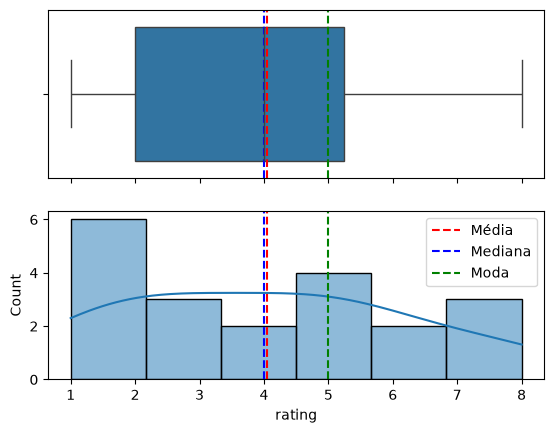

In [137]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)

sns.boxplot(data=df, x='rating', ax=ax_box)
ax_box.axvline(media, color = 'r', linestyle = '--')
ax_box.axvline(mediana, color = 'b', linestyle = '--')
ax_box.axvline(moda, color = 'g', linestyle = '--')

sns.histplot(data=df, x='rating', ax=ax_hist, kde=True)
ax_hist.axvline(media, color = 'r', linestyle = '--', label = 'Média')
ax_hist.axvline(mediana, color = 'b', linestyle = '--', label= 'Mediana')
ax_hist.axvline(moda, color = 'g', linestyle = '--', label = 'Moda')

plt.legend()

ax_box.set(xlabel='')
plt.show()

#### **Medidas de Dispersão**

- **Variância Amostral**:
$$
s^2 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

   Ao calcular a variância de uma **amostra**, a média populacional $(\mu)$ normalmente é desconhecida. Em seu lugar, utiliza-se a **média amostral** $(\bar{x})$, que é calculada a partir dos próprios dados da amostra.

   Como a média amostral é estimada usando as observações, ela impõe uma restrição aos desvios:

$$
\sum_{i=1}^{n}(x_i-\bar{x}) = 0
$$

   Isso significa que apenas **$n-1$ desvios são independentes**, pois o último é completamente determinado pelos demais. Dizemos que a amostra possui **$n-1$ graus de liberdade**.

   Se dividíssemos por $n$, a variância seria sistematicamente menor que a variância real da população, isto é, seria um **estimador viesado** (tenderia a subestimar a dispersão).

   Ao dividir por $n-1$, aplica-se a **Correção de Bessel**, tornando a variância amostral um **estimador não viesado** da variância populacional:

$$
E[s^2]=\sigma^2
$$

- **Desvio Padrão Amostral**:

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

  Obs: Como o desvio padrão é a **raiz quadrada da variância**, sua unidade de medida é a mesma dos dados originais, facilitando a interpretação.

- **Amplitude**:

$$
A = x_{(n)} - x_{(1)}
$$

- **Coeficiente de Variação**: Útil para comparar a variação de diferentes variáveis.

$$
CV = {\frac{s}{\bar{x}}}
$$

In [138]:
var = df['rating'].var(ddof=1)

std = df['rating'].std(ddof=1)

amplitude = df['rating'].max() - df['rating'].min()

cv = std/media

In [139]:
print(f"Variância Amostral: {var}")
print(f"Desvio Padrão Amostral: {std}")
print(f"Amplitude: {amplitude}")
print(f"Coeficiente de Variação: {cv:.2%}")

Variância Amostral: 4.997368421052632
Desvio Padrão Amostral: 2.235479461111784
Amplitude: 7
Coeficiente de Variação: 55.20%


#### **Medidas de Associação entre variáveis quantitativas**

- **Covariância (Amostral)**: A covariância avalia como duas variáveis variam em conjunto.

$$
\operatorname{Cov}(X, Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$
  
  **Limitação**: Apesar de ser útil para entender a direção da relação, a covariância tem uma grande limitação: o seu valor depende da unidade de medida das variáveis. Isso significa que não é possível dizer se a relação é "forte" ou "fraca" olhando apenas para o número bruto.

- **Coeficiente de Correlação de Pearson**: É uma medida estatística que avalia a força e a direção da relação linear entre duas variáveis quantitativas.

$$
r_{XY}
=
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}
}
$$

In [140]:
data = pd.DataFrame({
    "Horas_Estudo": [1, 2, 3, 4, 5, 6, 7, 8],
    "Nota":          [50, 55, 60, 65, 72, 78, 82, 90]
})

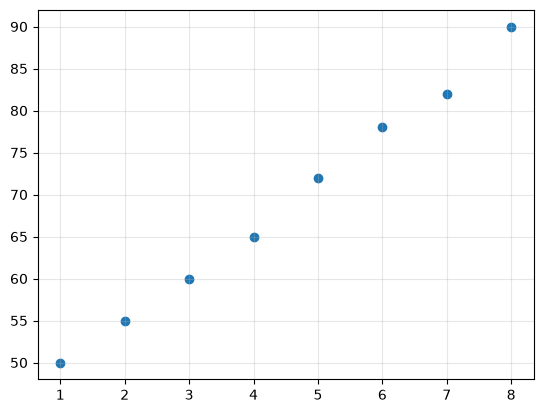

In [144]:
plt.scatter(data['Horas_Estudo'], data['Nota'])
plt.grid(alpha = 0.3)
plt.show()

In [141]:
cov = data["Horas_Estudo"].cov(data["Nota"])
print(f"Covariância: {cov:.2f}")

corr = data["Horas_Estudo"].corr(data["Nota"])
print(f"Correlação de Pearson: {corr:.4f}")

Covariância: 34.00
Correlação de Pearson: 0.9980
